# Outlier detection and removal using Percentile method

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('weight-height.csv')

In [5]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


## Plots to check destribution and outliers

C:\Users\91899\AppData\Local\Temp\ipykernel_27224\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

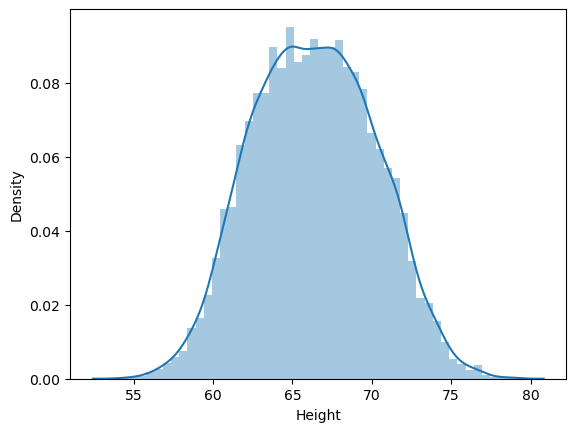

In [8]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

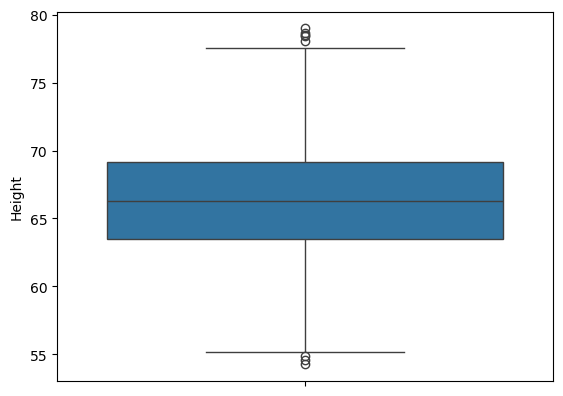

In [9]:
sns.boxplot(df['Height'])

In [11]:
upper_limit=df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)

In [13]:
lower_limit

np.float64(58.13441158671655)

In [15]:
upper_limit

np.float64(74.7857900583366)

In [21]:
df[(df['Height']>upper_limit) | (df['Height']<lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


## Outlier treaming

In [17]:
df_new=df[(df['Height']<upper_limit) & (df['Height']>lower_limit)]

In [20]:
df_new.shape

(9800, 3)

## Outlier capping

In [22]:
df['Height']=np.where(
    df['Height']<lower_limit,
    lower_limit,
    np.where(
        df['Height']>upper_limit,
        upper_limit,
        df['Height']
    )
)

In [25]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


## Plots after outlier detection and capping

C:\Users\91899\AppData\Local\Temp\ipykernel_27224\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

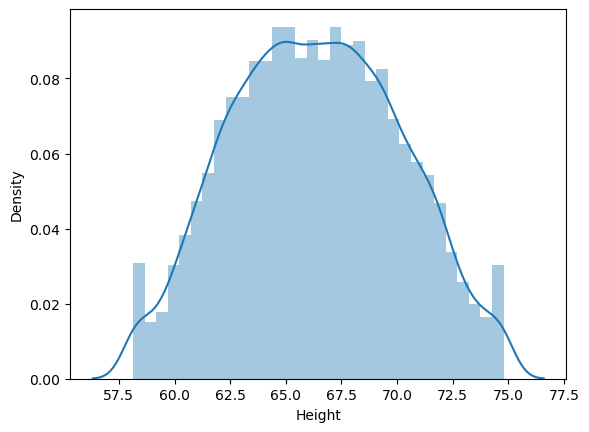

In [26]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

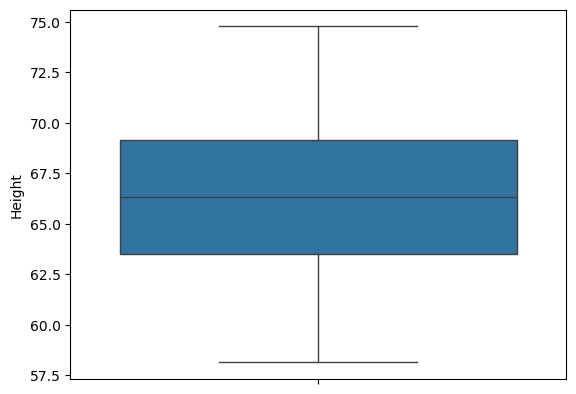

In [27]:
sns.boxplot(df['Height'])